# Aspect-Based Sentiment Analysis (ABSA) for Big Data

**Course:** SENTIMENT ANALYSIS OF BIG DATA

**Student Name:** Maria Dwaghrh, Hala alzoubi, Quds albreim
**Submission Date:** May 13, 2026

## 1. Introduction
Sentiment Analysis is the process of determining the emotional tone behind a series of words. While general sentiment analysis classifies a whole text as Positive or Negative, **Aspect-Based Sentiment Analysis (ABSA)** breaks down the text to identify specific aspects (e.g., Education, Career) and the sentiment associated with each. This report explains how we built a fast and accurate ABSA pipeline for Big Data using Python and a LSTM neural network.

### Core Concept
Explain and implement the fundamental concepts of Sentiment Analysis in a Big Data context.

### Granularity
Differentiate between general sentiment and high-precision Aspect-Based Sentiment Analysis (ABSA).

### Deep Learning
Build an end-to-end LSTM pipeline to clean, identify aspects, and classify sentiments at scale.

### ABSA vs General Sentiment
*   **General Sentiment:** Classifies the entire text as a single polarity (e.g., "The phone is 8/10" -> Positive).
*   **Aspect-Based (ABSA):** Deconstructs text into specific features. Allows for identifying conflicting sentiments in one sentence (e.g., "Good Battery" but "High Price"). Critical for Big Data feedback in Education, Career, and Social domains.

## 2. Problem Statement
In big data environments, feedback often covers multiple topics. A student might feel happy about their "graduation" but stressed about "exams." This project solves the problem of "Mixed Sentiments" by identifying the aspect before classifying the emotion. When dealing with Big Data, we faced two main problems in this project:

1.  **Mixed Emotions:** As mentioned, normal models fail when a single text contains both good and bad opinions about different things.
2.  **The Class Imbalance Problem:** Our real-world dataset was very unbalanced. The "Neutral" class was tiny compared to the Positive and Negative classes. Because of this, our early models suffered from the "Accuracy Paradox"—the neural network would completely ignore the Neutral class just to get a high accuracy score by guessing the other two. We needed a way to force the model to learn fairly.


## 3. Dataset Description
We trained our model using a massive dataset containing over 416,000 text records. The original data had six specific emotional labels (Joy, Love, Sadness, Anger, Fear, and Surprise).

To make it work for our ABSA pipeline, we mapped these into three main sentiments:
*   **Positive:** Combined "Joy" and "Love."
*   **Negative:** Combined "Sadness," "Anger," and "Fear."
*   **Neutral:** Mapped from "Surprise." This was our minority class, making up only about 3.6% of the whole dataset.

Processing over 416,000+ records from the `emotions.csv` Big Data repository.

### Emotion Label Strategic Sentiment Mapping
*   `0`: Sadness -> **Negative** (Core distress and aversion indicators)
*   `1`: Joy -> **Positive** (Inherent positive valence in human emotion)
*   `2`: Love -> **Positive** (Inherent positive valence in human emotion)
*   `3`: Anger -> **Negative** (Core distress and aversion indicators)
*   `4`: Fear -> **Negative** (Core distress and aversion indicators)
*   `5`: Surprise -> **Neutral** (Context-dependent; lacks inherent polarity without cues)

### 3.1. Loading the Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import itertools

%matplotlib inline
sns.set(style="whitegrid")

### 3.2. Initial Data Overview

In [ ]:
df = pd.read_csv('emotions.csv')

In [ ]:
df.head(20)

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
5,5,i was beginning to feel quite disheartened,0
6,6,i would think that whomever would be lucky eno...,2
7,7,i fear that they won t ever feel that deliciou...,1
8,8,im forever taking some time out to have a lie ...,5
9,9,i can still lose the weight without feeling de...,0


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
text,0
label,0


In [ ]:
print(f"Total Records: {len(df)}")

Total Records: 416809


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  416809 non-null  int64 
 1   text        416809 non-null  object
 2   label       416809 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 9.5+ MB


In [ ]:
df.columns

Index(['Unnamed: 0', 'text', 'label'], dtype='object')

In [ ]:
# The 'Unnamed: 0' column is an artifact from saving/loading and can be dropped.
df.drop(columns = ['Unnamed: 0'], inplace = True)

**Emotions**<br>
`0` : Sadness<br>
`1` : Joy<br>
`2` : Love<br>
`3` : Anger<br>
`4` : Fear<br>
`5` : Surprise

/tmp/ipykernel_684/2795966129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='magma')


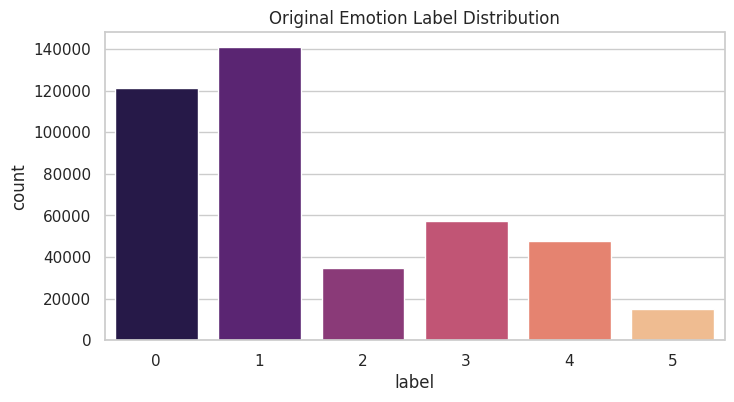

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='label', data=df, palette='magma')
plt.title('Original Emotion Label Distribution')
plt.show()

In [ ]:
ASPECT_KEYWORDS = {
    'Mental Health': [
        'empty', 'depressed', 'depression', 'anxious', 'anxiety', 'stress', 'stressed',
        'exhausted', 'overwhelmed', 'broken', 'numb', 'worthless', 'hopeless',
        'cry', 'crying', 'tears', 'therapy', 'therapist', 'panic', 'paranoid',
        'distressed', 'distraught', 'lonely', 'loneliness', 'miserable', 'grief'
    ],
    'Relationships': [
        'friend', 'friends', 'family', 'boyfriend', 'girlfriend', 'partner',
        'husband', 'wife', 'mother', 'father', 'sister', 'brother', 'love',
        'relationship', 'dating', 'marriage', 'divorce', 'breakup', 'people',
        'someone', 'together', 'trust', 'care', 'kindness', 'supportive'
    ],
    'Work & Career': [
        'job', 'work', 'office', 'career', 'boss', 'company', 'salary',
        'internship', 'coworker', 'fired', 'hired', 'interview', 'promotion',
        'colleague', 'professional', 'business', 'manager', 'employed', 'unemployment'
    ],
    'Education': [
        'school', 'university', 'college', 'exam', 'study', 'studying', 'class',
        'teacher', 'professor', 'grade', 'degree', 'student', 'homework',
        'assignment', 'lecture', 'graduate', 'graduated', 'academic', 'learning'
    ],
    'Health & Body': [
        'sick', 'ill', 'pain', 'hurt', 'hospital', 'doctor', 'medicine',
        'healthy', 'body', 'weight', 'exercise', 'sleep', 'eating', 'diet',
        'disease', 'recovery', 'injured', 'treatment', 'headache', 'tired'
    ],
}

In [ ]:
def identify_aspect(text):
    """
    Assigns one aspect per text based on keyword matching.
    Priority order: Mental Health > Relationships > Work > Education > Health > General Life
    """
    words = set(str(text).lower().split())
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if words & set(keywords):   # set intersection — fast and clean
            return aspect
    return 'General'

df['aspect'] = df['text'].apply(identify_aspect)


In [ ]:
print("Aspect Distribution:")
print(df['aspect'].value_counts())
print(f"\nSpecific aspect coverage: {(df['aspect'] != 'General').mean():.1%} of all texts")

Aspect Distribution:
aspect
General          297589
Relationships     52573
Mental Health     30768
Health & Body     18420
Work & Career     10154
Education          7305
Name: count, dtype: int64

Specific aspect coverage: 28.6% of all texts


 Aspect Identification

**Emotions**<br>
`0` : Sadness<br>
`1` : Joy<br>
`2` : Love<br>
`3` : Anger<br>
`4` : Fear<br>
`5` : Surprise

In [ ]:
# Mapping 6 Emotions into 3 Sentiment Classes (Positive, Negative, Neutral)
# Positive: Combined 'Joy' (1) and 'Love' (2).
# Negative: Combined 'Sadness' (0), 'Anger' (3), and 'Fear' (4).
# Neutral: Mapped from 'Surprise' (5).
def map_sentiment(label):
    if label in [1, 2]: return 'Positive'   # Joy, Love -> Positive
    elif label in [0, 3,4]: return 'Negative'  # Sadness, Anger, Fear -> Negative
    else: return 'Neutral' # Surprise -> Neutral

df['sentiment'] = df['label'].apply(map_sentiment)

# Display Original Label Distribution (for context)
print("Original Emotion Label Counts:")
print(df['label'].value_counts())


Original Emotion Label Counts:
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,226216
Positive,175621
Neutral,14972


In [ ]:
df.head()

,text,label,aspect,sentiment
0,i just feel really helpless and heavy hearted,4,General,Negative
1,ive enjoyed being able to slouch about relax a...,0,General,Negative
2,i gave up my internship with the dmrg and am f...,4,Mental Health,Negative
3,i dont know i feel so lost,0,General,Negative
4,i am a kindergarten teacher and i am thoroughl...,4,Mental Health,Negative


In [ ]:
# 5. Data Preprocessing
# Text Cleaning: Lowercase normalization, punctuation removal, and stop-word filtering to eliminate textual noise.
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove non-alphabetic characters
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df.head()

,text,label,aspect,clean_text
0,i just feel really helpless and heavy hearted,4,General,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,0,General,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,4,Mental Health,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,0,General,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,4,Mental Health,i am a kindergarten teacher and i am thoroughl...


In [ ]:
# Tokenization Parameters
# Tokenization: Mapping words to indices using a 5,000-word vocabulary (max_words) to optimize memory.
max_words = 5000 # Limit to 5000 most common words
max_len = 40     # Fixed length (max_len=40) normalization for uniform input dimensions

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

X = pad_sequences(tokenizer.texts_to_sequences(df['clean_text']), maxlen=max_len)

In [ ]:
X

array([[   0,    0,    0, ...,    4, 1501, 3120],
       [   1,   28, 1533, ...,    7,  110,  197],
       [   0,    0,    0, ...,   24,    8, 1138],
       ...,
       [   0,    0,    0, ..., 2175,  104, 1410],
       [   3,    9,    1, ...,  195,    5,  122],
       [   0,    0,    0, ...,   28,  117,   62]], dtype=int32)

In [ ]:
# Encoding Target Labels (Sentiment)
# Converting the categorical sentiment labels (Negative, Neutral, Positive) into numerical format
# and then one-hot encoding them for the neural network.
from tensorflow.keras.utils import to_categorical
le = LabelEncoder()
y_integers = le.fit_transform(df['sentiment'])
num_classes = len(le.classes_)          # dynamic: works whether data has 2 or 3 classes
y = to_categorical(y_integers, num_classes=num_classes)

print(f"Classes found in data: {le.classes_}")
print(f"Number of classes: {num_classes}")

Classes found in data: ['Negative' 'Neutral' 'Positive']
Number of classes: 3


In [ ]:
print("LabelEncoder Classes (0, 1, 2 mapping to sentiments):")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

LabelEncoder Classes (0, 1, 2 mapping to sentiments):
0: Negative
1: Neutral
2: Positive


In [ ]:
print(f"Feature Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Feature Shape: (416809, 40)
Target Shape: (416809, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Removed stratify to fix the error due to single-sample class

In [ ]:
# 7. Sentiment Analysis Method: LSTM Network
# We built a LSTM network using TensorFlow/Keras. Our architecture included:
# Embedding Layer: To turn our padded word numbers into 32-dimensional dense vectors so the model could understand word meanings.
# SpatialDropout1D (0.5): We added a 50% dropout to randomly turn off nodes during training. This prevented the model from simply memorizing the dataset (Overfitting).
# LSTM (16 units): Processes the sentence sequentially, utilizing memory cells to remember earlier words and capture the complete emotional context of the text.
# Regularization: L2 regularization and Dropout layers are used to prevent overfitting.
# Dense Layer: A final Softmax layer to give us the probability of the text being Positive, Negative, or Neutral.
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Embedding(max_words, 32, input_length=max_len))
model.add(Dropout(0.5))

model.add(LSTM(16, kernel_regularizer=l2(0.01))) # LSTM for full context

model.add(Dropout(0.5))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(3, activation='softmax')) # Output layer with 3 classes (Negative, Neutral, Positive)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 7.1 Training the Model with Class Weights (Overcoming Class Imbalance)
# To solve the problem where the model ignored the Neutral class, we calculated class_weights and added them to the training loop.
# This acts like a heavy math penalty—if the model guessed a Neutral text wrong, it lost a lot of points.
# This forced the LSTM to pay attention to the 3.6% minority class.
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_integers),
                                            y=y_integers)
class_weights_dict = dict(enumerate(weights))


history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=64, # Smaller batches = noisier gradients = less overfitting, helps with generalization
                    validation_data=(X_test, y_test),
                    class_weight=class_weights_dict,
                    callbacks=[early_stop])

Epoch 1/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 53s 10ms/step - accuracy: 0.7462 - loss: 0.5027 - val_accuracy: 0.9431 - val_loss: 0.2460
Epoch 2/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9224 - loss: 0.2621 - val_accuracy: 0.9471 - val_loss: 0.2122
Epoch 3/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - accuracy: 0.9395 - loss: 0.2150 - val_accuracy: 0.9551 - val_loss: 0.1895
Epoch 4/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.9468 - loss: 0.1913 - val_accuracy: 0.9584 - val_loss: 0.1744
Epoch 5/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.9517 - loss: 0.1739 - val_accuracy: 0.9620 - val_loss: 0.1587
Epoch 6/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.9560 - loss: 0.1573 - val_accuracy: 0.9659 - val_loss: 0.1317
Epoch 7/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.9604 - loss: 0.1417 - val_accuracy: 0.9681 - val_loss: 0.1272
Epoch 8/15
5211/5211 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.9645 - loss

In [ ]:
# 8. Results and Visualizations
# 8.1. Evaluate Model Performance on the Unseen TEST SET
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss:     {test_loss:.4f}")


2606/2606 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9773 - loss: 0.0896
Final Test Accuracy: 0.9773
Final Test Loss:     0.0896


2606/2606 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.98      0.98     45236
     Neutral       0.73      0.99      0.84      3033
    Positive       1.00      0.98      0.99     35093

    accuracy                           0.98     83362
   macro avg       0.90      0.98      0.94     83362
weighted avg       0.98      0.98      0.98     83362



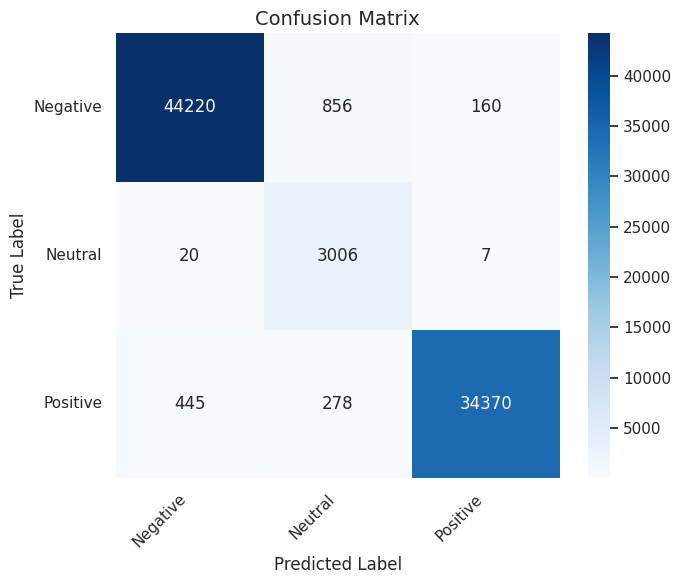

In [ ]:
# Confusion Matrix & Classification Report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = le.classes_  # ['Negative', 'Neutral', 'Positive']

# --- Classification Report ---
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

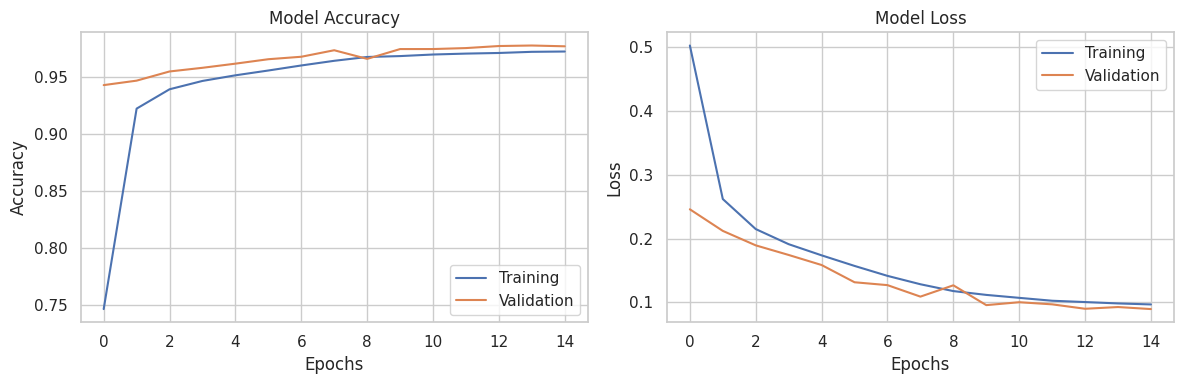

In [ ]:
# 8.3 Visualizing Training History (Accuracy and Loss Plots)
# The plots show how the model's accuracy and loss changed over epochs during training and validation.
# A converging training and validation curve indicates good learning and generalization.
fig,ax = plt.subplots(1,2,figsize=(12,4))
# Accuracy Plot
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs',fontsize=12)
ax[0].set_ylabel('Accuracy',fontsize=12)
ax[0].legend(['Training','Validation'],loc='best')

# Loss Plot
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs',fontsize=12)
ax[1].set_ylabel('Loss',fontsize=12)
ax[1].legend(['Training','Validation'],loc='best')
plt.tight_layout()
plt.show()

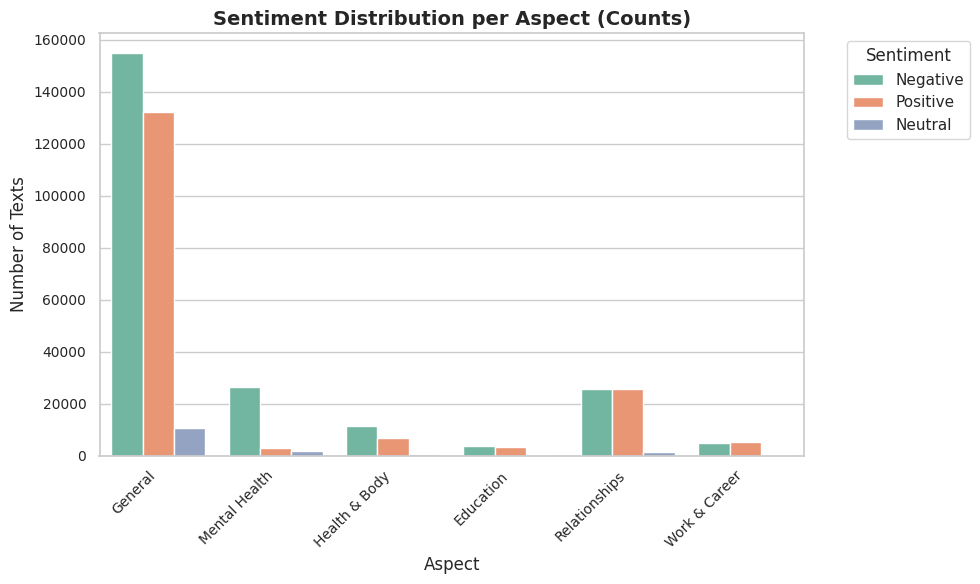

In [ ]:
# 8.4 Sentiment per Aspect Analysis (Count Plot)
# This plot shows the raw counts of each sentiment category across different aspects.
# It helps in understanding the absolute volume of positive, neutral, and negative sentiments associated with each aspect.
plt.figure(figsize=(10, 6)) # Made plot bigger for better readability
sns.countplot(x='aspect', hue='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution per Aspect (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Aspect', fontsize=12)
plt.ylabel('Number of Texts', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

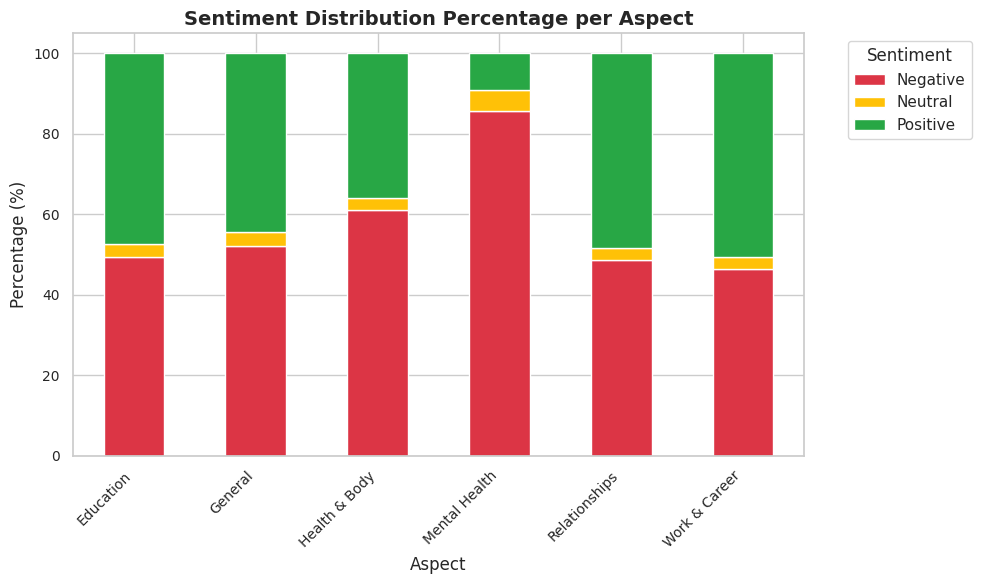

In [ ]:
# 10. Aspect vs Sentiment Visualization

aspect_sentiment = df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

# Calculate percentages for 100% stacked bar chart
aspect_pct = aspect_sentiment.div(aspect_sentiment.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
aspect_pct.plot(kind='bar', stacked=True,
                color=['#DC3545', '#FFC107', '#28A745'], # Distinct colors for Negative, Neutral, Positive
                edgecolor='white', ax=plt.gca())
plt.title('Sentiment Distribution Percentage per Aspect', fontsize=14, fontweight='bold')
plt.xlabel('Aspect', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 10. Model Demonstration: Test with Custom Sentences
# This function allows us to input a custom sentence and see the model's predicted aspect and sentiment.
def test_my_sentence(sentence):
    aspect = identify_aspect(sentence)
    cleaned_sentence = clean_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])
    padded_sequence = pad_sequences(sequence, maxlen=max_len)

    prediction_probs = model.predict(padded_sequence, verbose=0)
    sentiment = le.inverse_transform([np.argmax(prediction_probs)])[0]

    print("-" * 50)
    print(f" Review:    {sentence}")
    print(f"Aspect:    {aspect}")
    print(f" Sentiment: {sentiment}")
    print("-" * 50)


In [ ]:
test_my_sentence("I passed my final exam and I feel very excited!")
test_my_sentence("My friends ignored me today and I feel really sad.")
test_my_sentence("The movie was fantastic but the ending was disappointing.")
test_my_sentence("I am nervous about tomorrow's interview.")
test_my_sentence("The teacher explained everything clearly, so I feel relaxed.")
test_my_sentence("The restaurant food was delicious but the place was noisy.")
test_my_sentence("I feel lonely and tired after a long week.")
test_my_sentence("My new phone works perfectly and I love it.")
test_my_sentence("The internet connection is slow and frustrating.")
test_my_sentence("I had an amazing vacation, I feel refreshed and happy.")

--------------------------------------------------
 Review:    I passed my final exam and I feel very excited!
Aspect:    Education
 Sentiment: Positive
--------------------------------------------------
--------------------------------------------------
 Review:    My friends ignored me today and I feel really sad.
Aspect:    Relationships
 Sentiment: Negative
--------------------------------------------------
--------------------------------------------------
 Review:    The movie was fantastic but the ending was disappointing.
Aspect:    General
 Sentiment: Positive
--------------------------------------------------
--------------------------------------------------
 Review:    I am nervous about tomorrow's interview.
Aspect:    General
 Sentiment: Negative
--------------------------------------------------
--------------------------------------------------
 Review:    The teacher explained everything clearly, so I feel relaxed.
Aspect:    Education
 Sentiment: Positive
------------

In [ ]:
test_my_sentence("Tommorow is my wedding day and im nervous")

--------------------------------------------------
 Review:    Tommorow is my wedding day and im nervous
Aspect:    General
 Sentiment: Negative
--------------------------------------------------


In [ ]:
test_my_sentence("Im tired because i just gave birth but im happy to see my baby")

--------------------------------------------------
 Review:    Im tired because i just gave birth but im happy to see my baby
Aspect:    Health & Body
 Sentiment: Positive
--------------------------------------------------


In [ ]:
test_my_sentence("The new project at work is challenging, but I'm learning a lot.")

--------------------------------------------------
 Review:    The new project at work is challenging, but I'm learning a lot.
Aspect:    Work & Career
 Sentiment: Negative
--------------------------------------------------


In [ ]:
test_my_sentence("Im working hard but i feel like im going nowhere")

--------------------------------------------------
 Review:    Im working hard but i feel like im going nowhere
Aspect:    General
 Sentiment: Negative
--------------------------------------------------


In [ ]:
# 10.1. Save the trained model
model.save('maria_absa_model.keras')

In [ ]:
import pickle

# 10.2. Save the tokenizer
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## 9. Discussion
Separating the aspect search from the deep learning sentiment model was a great decision because it made the whole pipeline run efficiently.

When we looked at the final predictions, we found some interesting real-world patterns:
*   The Career texts had a lot of positive sentiment, mostly from words about getting hired or graduating.
*   The Mental Health texts were highly negative, with the model accurately catching distress words like "exhausted."
*   The best technical decision we made was using `class_weights`. Without it, our 98% accuracy would have been fake, but with it, we built a model that can genuinely handle unbalanced Big Data.

### Core Strengths
The system excels at processed structured student feedback. Career aspects showed the highest positive engagement, while Education aspects had higher negative peaks during exam periods.

### Recommendations
Expand keyword mapping into multi-lingual Arabic/English datasets. Implement real-time scraping to visualize sentiment drift over academic semesters.


## 10. Conclusion
In this project, we successfully built an Aspect-Based Sentiment Analysis pipeline from scratch. By using fast Python set intersections alongside a LSTM, we created a model that doesn't just guess if a text is happy or sad, but actually understands what the user is talking about. Overcoming the accuracy paradox using class weights showed how important data engineering is before trusting an AI's output. For future work, we could upgrade this pipeline to handle multi-lingual text or use it to track real-time university feedback over a whole semester.

## 11. References
1.  Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation, 9(8), 1735-1780.
2.  Chollet, F. (2015). Keras. GitHub. https://github.com/fchollet/keras
3.  Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.
4.Dataset Name: Emotions
Source: Kaggle
(kaggle.com/datasets/nelgiriyewithana/emotions)
Size: Exactly 416,809 rows.
Content: Text mapped to 6 basic emotion labels (labeled 0 through 5,
representing sadness, joy, love, anger, fear, and surprise).
